<a href="https://colab.research.google.com/github/GUEST72/CSC311-Machine-Learning-projects/blob/main/assignment_2%5CCustom_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score
import os

#Set_device (use GPU if available, otherwise use CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.manual_seed(27)

Using device: cpu


In [7]:
# Transform: Normalize to [0,1] (ToTensor does this)
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])


# Load MNIST train and test sets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Combine them to split across all data
full_dataset = ConcatDataset([train_dataset, test_dataset])
# Get all labels for stratification
labels = [full_dataset[i][1] for i in range(len(full_dataset))]

# Split indices: 60% train, 40% temp (then split temp into 50% val, 50% test → 20% each)
train_idx, temp_idx = train_test_split(range(len(full_dataset)), test_size=0.4, stratify=labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[labels[i] for i in temp_idx], random_state=42)

# Create subsets
train_set = Subset(full_dataset, train_idx)
val_set = Subset(full_dataset, val_idx)
test_set = Subset(full_dataset, test_idx)

# Function to create DataLoaders (we'll use this later with different batch sizes)
def get_dataloaders(batch_size=64):
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader

# Create baseline loaders
train_loader, val_loader, test_loader = get_dataloaders()

print(f"Train size: {len(train_set)}, Val size: {len(val_set)}, Test size: {len(test_set)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.85MB/s]


Train size: 42000, Val size: 14000, Test size: 14000


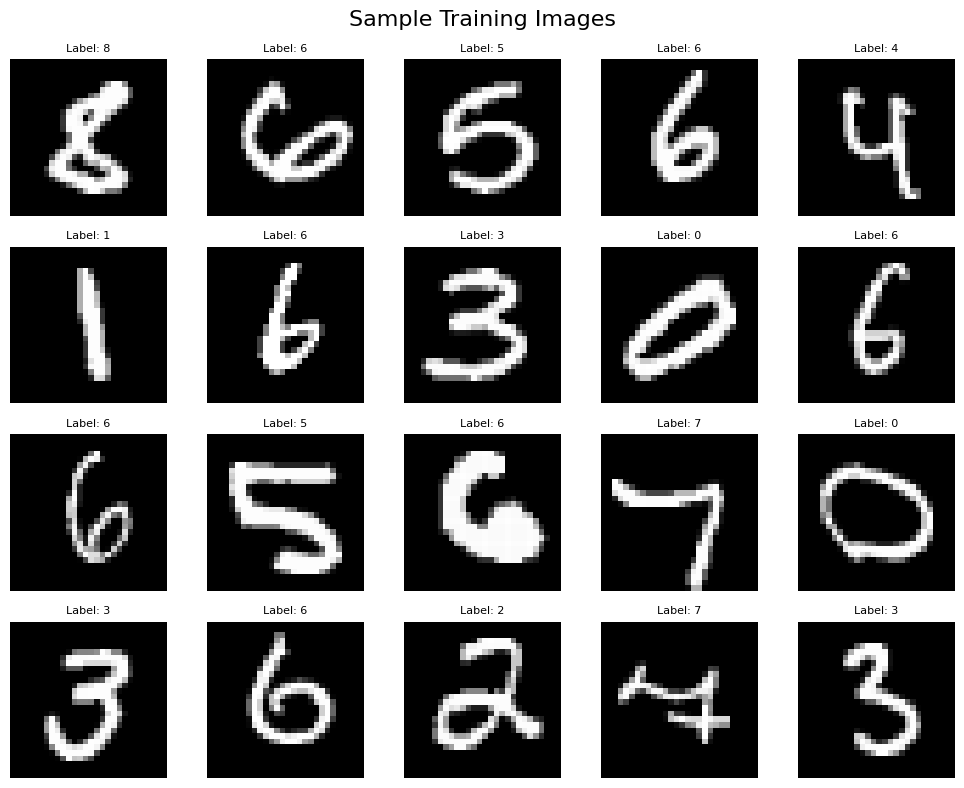

In [4]:
# Get a sample
dataiter = iter(train_loader)
images, labels = next(dataiter)


fig, axes = plt.subplots(4, 5, figsize=(10, 8))
fig.suptitle("Sample Training Images", fontsize=16)
for idx, ax in enumerate(axes.flat):
    ax.imshow(images[idx].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[idx].item()}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [8]:
class CustomNN(nn.Module):
    # Define the neural network architecture
    def __init__(self, input_size=784, hidden_sizes=[128, 64], output_size=10, dropout_prob=0.0, use_batchnorm=False):
        super(CustomNN, self).__init__()
        # Flexible: hidden_sizes is a list for multiple hidden layers
        self.activation_fn = nn.ReLU() # Using ReLU as the activation function

        # Create a list to hold the layers of the network
        self.layers = nn.ModuleList()
        prev_size = input_size # Initialize the size of the input to the first layer

        # Build the hidden layers based on the hidden_sizes list
        for hidden_size in hidden_sizes:

            # Add a linear (fully connected) layer
            layer = nn.Linear(prev_size, hidden_size)
            nn.init.xavier_uniform_(layer.weight)  # Initialize weights using Xavier uniform initialization

            self.layers.append(layer)

            # Optionally add Batch Normalization
            if use_batchnorm:
                self.layers.append(nn.BatchNorm1d(hidden_size))

            # Add the activation function after the linear layer (and BatchNorm if used)
            self.layers.append(self.activation_fn)

            # Optionally add Dropout for regularization
            if dropout_prob > 0:
                self.layers.append(nn.Dropout(p=dropout_prob))

            prev_size = hidden_size # Update the input size for the next layer

        # Add the output layer
        self.output = nn.Linear(prev_size, output_size)
        nn.init.xavier_uniform_(self.output.weight) # Initialize weights for the output layer

    # Define the forward pass of the network
    def forward(self, x):
        # Flatten the input image
        x = x.view(x.size(0), -1)  # Reshape to batch_size x (input_size)

        # Pass the input through the sequence of hidden layers
        for layer in self.layers:
           x = layer(x)

        # Pass the output of the hidden layers through the final output layer
        x = self.output(x)
        return x # Return the output logits

In [9]:
class EarlyStopping:


    def __init__(self, patience=7, min_delta=0.0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights

        self.best_loss = float('inf')
        self.counter = 0
        self.best_weights = None
        self.early_stop = False

    def __call__(self, val_loss, model):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss
            self.counter = 0

            if self.restore_best_weights:

                self.best_weights = {name: param.clone() for name, param in model.named_parameters()}
        else:

            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

                if self.restore_best_weights and self.best_weights is not None:

                    for name, param in model.named_parameters():
                        param.data.copy_(self.best_weights[name])

        return self.early_stop

In [10]:
def run_epoch(model, loader, criterion, optimizer=None):
    # Determine if it's a training epoch based on whether an optimizer is provided
    is_train = optimizer is not None
    # Set the model to training mode if optimizer is provided, otherwise set to evaluation mode
    model.train() if is_train else model.eval()

    total_loss, total_correct = 0, 0

    for images, labels in loader:
        # Move data to the specified device (GPU)
        images, labels = images.to(device), labels.to(device)

        # Perform forward pass: get model predictions (logits)
        outputs = model(images)

        # Calculate the loss between model outputs and true labels
        loss = criterion(outputs, labels)

        # Perform backward pass and optimization only in training mode
        if is_train:
            optimizer.zero_grad() # Clear previous gradients
            loss.backward()       # Compute gradient of the loss with respect to model parameters
            optimizer.step()      # Update model parameters using the gradients and optimizer

        # Accumulate loss and count correct predictions
        total_loss += loss.item() * images.size(0) # Sum of loss for each sample in the batch
        # Get the index of the max log-probability (the predicted class)
        # Compare predictions with true labels and sum up correct ones
        total_correct += (outputs.argmax(1) == labels).sum().item()

    # Calculate average loss and accuracy for the entire epoch
    avg_loss = total_loss / len(loader.dataset)
    avg_acc = total_correct / len(loader.dataset)
    return avg_loss, avg_acc

In [11]:
def train_model(model, train_loader, val_loader, lr=0.01, epochs=20, patience=5, min_delta=0.001, verbose=True):

    model = model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    early_stopping = EarlyStopping(patience=patience, min_delta=min_delta, restore_best_weights=True)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    if verbose:
        print(f"Training with Early Stopping (patience={patience}, min_delta={min_delta})")

    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")


        if early_stopping(val_loss, model):
            if verbose:
                print(f"Early stopping triggered at epoch {epoch+1}")
                print(f"Best validation loss: {early_stopping.best_loss:.4f}")
            break

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'stopped_early': early_stopping.early_stop,
        'best_val_loss': early_stopping.best_loss,
        'epochs_trained': len(train_losses)
    }


Training with Early Stopping (patience=5, min_delta=0.001)
Epoch 1/100 | Train Loss: 1.0265 Acc: 0.7445 | Val Loss: 0.4923 Acc: 0.8715
Epoch 2/100 | Train Loss: 0.4090 Acc: 0.8893 | Val Loss: 0.3642 Acc: 0.8989
Epoch 3/100 | Train Loss: 0.3320 Acc: 0.9078 | Val Loss: 0.3258 Acc: 0.9069
Epoch 4/100 | Train Loss: 0.2939 Acc: 0.9176 | Val Loss: 0.3001 Acc: 0.9127
Epoch 5/100 | Train Loss: 0.2688 Acc: 0.9249 | Val Loss: 0.2777 Acc: 0.9204
Epoch 6/100 | Train Loss: 0.2495 Acc: 0.9298 | Val Loss: 0.2588 Acc: 0.9253
Epoch 7/100 | Train Loss: 0.2333 Acc: 0.9345 | Val Loss: 0.2525 Acc: 0.9255
Epoch 8/100 | Train Loss: 0.2203 Acc: 0.9379 | Val Loss: 0.2337 Acc: 0.9309
Epoch 9/100 | Train Loss: 0.2076 Acc: 0.9415 | Val Loss: 0.2376 Acc: 0.9284
Epoch 10/100 | Train Loss: 0.1976 Acc: 0.9434 | Val Loss: 0.2159 Acc: 0.9364
Epoch 11/100 | Train Loss: 0.1877 Acc: 0.9465 | Val Loss: 0.2126 Acc: 0.9379
Epoch 12/100 | Train Loss: 0.1788 Acc: 0.9492 | Val Loss: 0.2025 Acc: 0.9396
Epoch 13/100 | Train Loss:

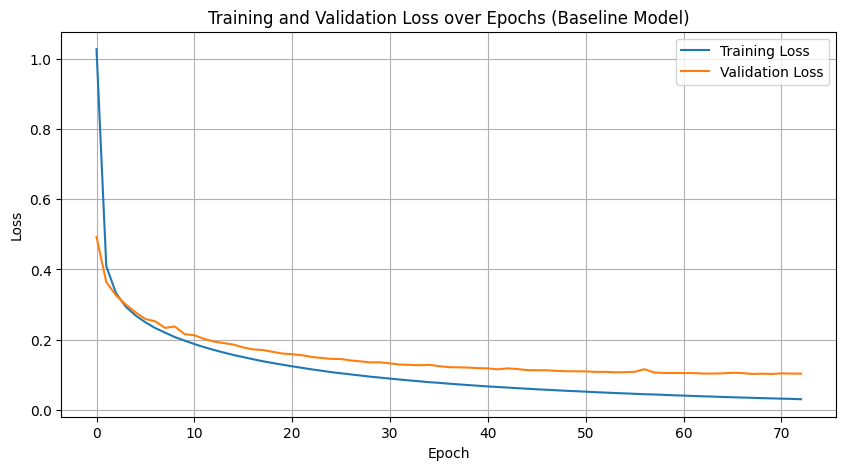

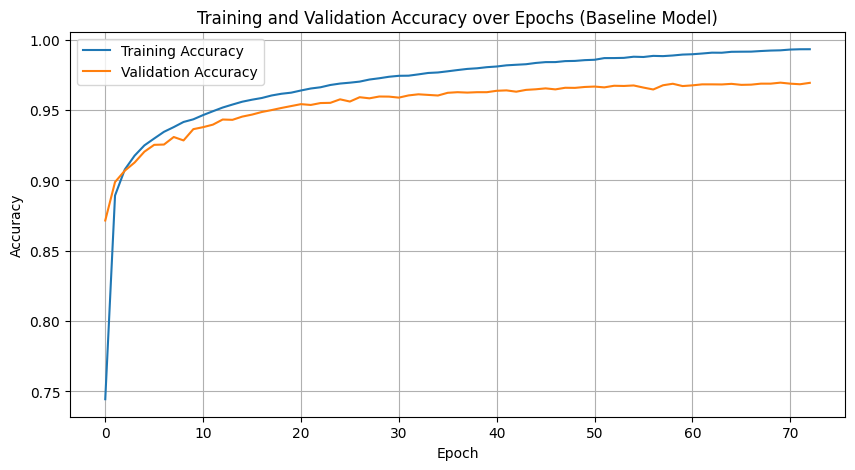


Running 5 trials for error bars...
Trial 1/5
Trial 2/5
Trial 3/5
Trial 4/5
Trial 5/5


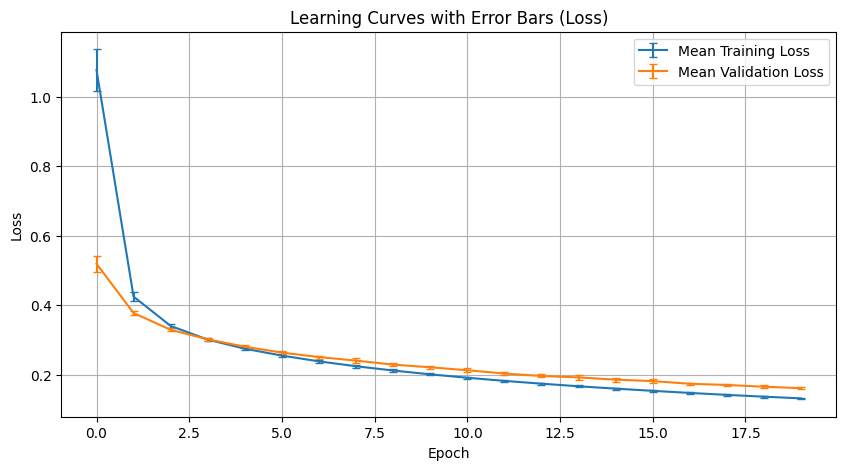

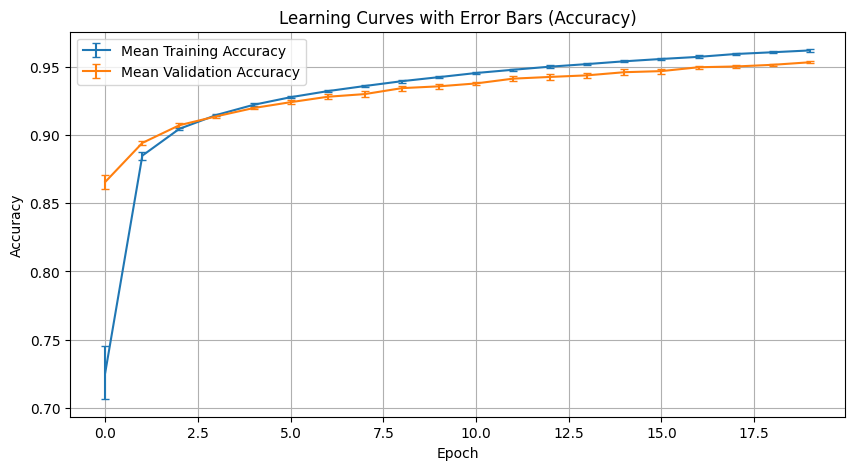

In [9]:
baseline_model = CustomNN()
baseline_history = train_model(baseline_model, train_loader, val_loader, lr=0.01, epochs=100, verbose=True)


# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(baseline_history['train_losses'], label='Training Loss')
plt.plot(baseline_history['val_losses'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs (Baseline Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training and Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(baseline_history['train_accs'], label='Training Accuracy')
plt.plot(baseline_history['val_accs'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs (Baseline Model)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Learning curves with error bars - This requires running multiple trials
# We will run the training multiple times with different random seeds
num_seeds = 5 # Number of runs for error bars
num_epochs = 20 # Number of epochs for each run
lr = 0.01 # Learning rate for baseline model

all_train_losses = []
all_val_losses = []
all_train_accs = []
all_val_accs = []

print(f"\nRunning {num_seeds} trials for error bars...")
for s in range(num_seeds):
    print(f"Trial {s+1}/{num_seeds}")
    torch.manual_seed(s) # Set different seed for each run
    model = CustomNN()
    history = train_model(model, train_loader, val_loader, lr=lr, epochs=num_epochs, verbose=False)
    all_train_losses.append(history['train_losses'])
    all_val_losses.append(history['val_losses'])
    all_train_accs.append(history['train_accs'])
    all_val_accs.append(history['val_accs'])

# Convert lists of lists to numpy arrays for easier calculation
all_train_losses = np.array(all_train_losses)
all_val_losses = np.array(all_val_losses)
all_train_accs = np.array(all_train_accs)
all_val_accs = np.array(all_val_accs)

# Calculate mean and standard deviation
mean_train_losses = np.mean(all_train_losses, axis=0)
std_train_losses = np.std(all_train_losses, axis=0)
mean_val_losses = np.mean(all_val_losses, axis=0)
std_val_losses = np.std(all_val_losses, axis=0)

mean_train_accs = np.mean(all_train_accs, axis=0)
std_train_accs = np.std(all_train_accs, axis=0)
mean_val_accs = np.mean(all_val_accs, axis=0)
std_val_accs = np.std(all_val_accs, axis=0)


# Plot Learning Curves with Error Bars (Loss)
plt.figure(figsize=(10, 5))
plt.errorbar(range(num_epochs), mean_train_losses, yerr=std_train_losses, label='Mean Training Loss', capsize=3)
plt.errorbar(range(num_epochs), mean_val_losses, yerr=std_val_losses, label='Mean Validation Loss', capsize=3)
plt.title('Learning Curves with Error Bars (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Learning Curves with Error Bars (Accuracy)
plt.figure(figsize=(10, 5))
plt.errorbar(range(num_epochs), mean_train_accs, yerr=std_train_accs, label='Mean Training Accuracy', capsize=3)
plt.errorbar(range(num_epochs), mean_val_accs, yerr=std_val_accs, label='Mean Validation Accuracy', capsize=3)
plt.title('Learning Curves with Error Bars (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Convergence Analysis
The plots above illustrate the convergence behavior of the baseline model.
- The **Loss over Epochs** plot shows how the training and validation loss decrease as training progresses. Convergence is typically reached when the loss stops decreasing significantly."

- The **Accuracy over Epochs** plot shows how the training and validation accuracy increase. Convergence is typically reached when the accuracy plateaus.

- The **Learning Curves with Error Bars** plots provide a more robust view of convergence by showing the average performance and variability across multiple training runs. Narrow error bars indicate consistent convergence."


In [18]:
results_lr, results_bs, results_arch = [], [], []

In [19]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
for lr in learning_rates:
    print(f"\n[LR Test] Learning Rate = {lr}")
    model = CustomNN()
    history = train_model(model, train_loader, val_loader, lr=lr, epochs=10,verbose=False)
    results_lr.append({
        'LR': lr,
        'Final Train Acc': history['train_accs'][-1],
        'Final Val Acc': history['val_accs'][-1],
        'Train Loss Curve': history['train_losses'],
        'Val Loss Curve': history['val_losses']
    })


[LR Test] Learning Rate = 0.001

[LR Test] Learning Rate = 0.01

[LR Test] Learning Rate = 0.1

[LR Test] Learning Rate = 1.0


In [20]:
def analyze_gradient_noise(model, data_loader, criterion, num_batches=5):
    model.train()
    gradients = []

    batch_count = 0
    for images, labels in data_loader:
        if batch_count >= num_batches:
            break

        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        model.zero_grad()
        loss.backward()


        batch_grad_norm = 0
        for param in model.parameters():
            if param.grad is not None:
                batch_grad_norm += param.grad.norm().item() ** 2

        gradients.append(batch_grad_norm ** 0.5)
        batch_count += 1


    grad_variance = np.var(gradients)
    grad_std = np.std(gradients)
    grad_mean = np.mean(gradients)

    # Gradient Noise Level = variance / mean^2
    noise_level = grad_variance / (grad_mean ** 2) if grad_mean > 0 else 0

    return {
        'gradient_variance': grad_variance,
        'gradient_std': grad_std,
        'gradient_mean': grad_mean,
        'noise_level': noise_level
    }

In [21]:
batch_sizes = [16, 32, 64, 128]
results_bs_enhanced = []

for bs in batch_sizes:
    print(f"\n[Batch Size Test] BS = {bs}")
    train_loader_bs, val_loader_bs, _ = get_dataloaders(batch_size=bs)


    model = CustomNN()
    model.to(device)
    criterion = nn.CrossEntropyLoss()


    initial_noise = analyze_gradient_noise(model, train_loader_bs, criterion)


    history = train_model(model, train_loader_bs, val_loader_bs, lr=0.01, epochs=10, verbose=False)

    final_noise = analyze_gradient_noise(model, train_loader_bs, criterion)

    results_bs_enhanced.append({
        'Batch Size': bs,
        'Final Train Acc': history['train_accs'][-1],
        'Final Val Acc': history['val_accs'][-1],
        'Initial Gradient Noise': initial_noise['noise_level'],
        'Final Gradient Noise': final_noise['noise_level'],
        'Gradient Variance': initial_noise['gradient_variance'],
    })

    print(f"  Final Val Acc: {history['val_accs'][-1]:.4f}")
    print(f"  Initial Gradient Noise: {initial_noise['noise_level']:.6f}")
    print(f"  Final Gradient Noise: {final_noise['noise_level']:.6f}")



[Batch Size Test] BS = 16
  Final Val Acc: 0.9634
  Initial Gradient Noise: 0.005470
  Final Gradient Noise: 0.042069

[Batch Size Test] BS = 32
  Final Val Acc: 0.9511
  Initial Gradient Noise: 0.012753
  Final Gradient Noise: 0.080147

[Batch Size Test] BS = 64
  Final Val Acc: 0.9351
  Initial Gradient Noise: 0.003249
  Final Gradient Noise: 0.082776

[Batch Size Test] BS = 128
  Final Val Acc: 0.9195
  Initial Gradient Noise: 0.001083
  Final Gradient Noise: 0.025090


In [22]:
layer_options = [2, 3, 4, 5]
neurons_options = [64, 128, 256, 512]

for layers in layer_options:
    for neurons in neurons_options:
        hidden_sizes = [neurons] * layers
        print(f"\n[Arch Test] Layers = {layers}, Neurons = {neurons}")
        model = CustomNN(hidden_sizes=hidden_sizes)
        history = train_model(model, train_loader, val_loader, lr=0.01, epochs=10,verbose=False)
        results_arch.append({
            'Layers': layers,
            'Neurons per Layer': neurons,
            'Final Train Acc': history['train_accs'][-1],
            'Final Val Acc': history['val_accs'][-1]
        })


[Arch Test] Layers = 2, Neurons = 64

[Arch Test] Layers = 2, Neurons = 128

[Arch Test] Layers = 2, Neurons = 256

[Arch Test] Layers = 2, Neurons = 512

[Arch Test] Layers = 3, Neurons = 64

[Arch Test] Layers = 3, Neurons = 128

[Arch Test] Layers = 3, Neurons = 256

[Arch Test] Layers = 3, Neurons = 512

[Arch Test] Layers = 4, Neurons = 64

[Arch Test] Layers = 4, Neurons = 128

[Arch Test] Layers = 4, Neurons = 256

[Arch Test] Layers = 4, Neurons = 512

[Arch Test] Layers = 5, Neurons = 64

[Arch Test] Layers = 5, Neurons = 128

[Arch Test] Layers = 5, Neurons = 256

[Arch Test] Layers = 5, Neurons = 512


In [23]:
df_lr = pd.DataFrame(results_lr)
df_bs_enhanced = pd.DataFrame(results_bs_enhanced)
df_arch = pd.DataFrame(results_arch)

print("\n=== Learning Rate Results ===")
print(df_lr[['LR', 'Final Train Acc', 'Final Val Acc']])
print(df_bs_enhanced[['Batch Size', 'Final Val Acc', 'Initial Gradient Noise', 'Final Gradient Noise',]])

print("\n=== Architecture Results ===")
print(df_arch)



=== Learning Rate Results ===
      LR  Final Train Acc  Final Val Acc
0  0.001         0.865048       0.865929
1  0.010         0.943524       0.936929
2  0.100         0.990643       0.974000
3  1.000         0.972571       0.954643
   Batch Size  Final Val Acc  Initial Gradient Noise  Final Gradient Noise
0          16       0.963357                0.005470              0.042069
1          32       0.951143                0.012753              0.080147
2          64       0.935071                0.003249              0.082776
3         128       0.919500                0.001083              0.025090

=== Architecture Results ===
    Layers  Neurons per Layer  Final Train Acc  Final Val Acc
0        2                 64         0.935500       0.929429
1        2                128         0.942286       0.937000
2        2                256         0.944381       0.936571
3        2                512         0.947881       0.940429
4        3                 64         0.949357   

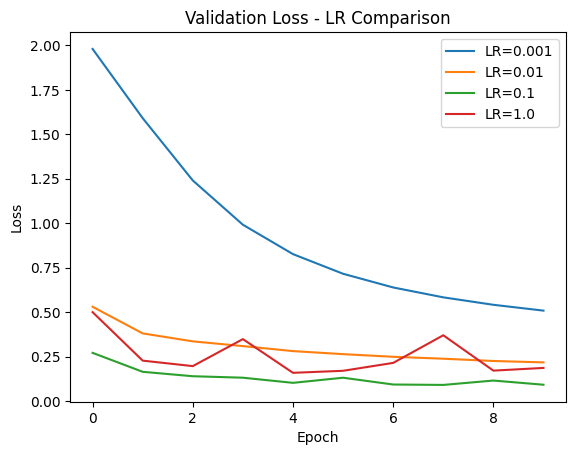

In [24]:
plt.figure()
for res in results_lr:
    plt.plot(res['Val Loss Curve'], label=f"LR={res['LR']}")
plt.title("Validation Loss - LR Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [25]:
dropout_rates = [0.1, 0.3, 0.5, 0.7]
use_bn_options = [False, True]

results = []

for bn in use_bn_options:
    for dr in dropout_rates:
        print(f"\n=== Running: Dropout={dr}, BatchNorm={bn} ===")
        model = CustomNN(dropout_prob=dr, use_batchnorm=bn)
        history = train_model(model, train_loader, val_loader, lr=0.01, epochs=10,verbose=False)

        results.append({
            'Dropout': dr,
            'BatchNorm': bn,
            'Final Train Acc': history['train_accs'][-1],
            'Final Val Acc': history['val_accs'][-1],
            'Train Loss Curve': history['train_losses'],
            'Val Loss Curve': history['val_losses'],
            'Train Acc Curve': history['train_accs'],
            'Val Acc Curve': history['val_accs']
        })



=== Running: Dropout=0.1, BatchNorm=False ===

=== Running: Dropout=0.3, BatchNorm=False ===

=== Running: Dropout=0.5, BatchNorm=False ===

=== Running: Dropout=0.7, BatchNorm=False ===

=== Running: Dropout=0.1, BatchNorm=True ===

=== Running: Dropout=0.3, BatchNorm=True ===

=== Running: Dropout=0.5, BatchNorm=True ===

=== Running: Dropout=0.7, BatchNorm=True ===


In [26]:
df_results = pd.DataFrame(results)
print(df_results[['Dropout', 'BatchNorm', 'Final Train Acc', 'Final Val Acc']])


   Dropout  BatchNorm  Final Train Acc  Final Val Acc
0      0.1      False         0.927619       0.939000
1      0.3      False         0.903786       0.931071
2      0.5      False         0.866667       0.920929
3      0.7      False         0.759548       0.904929
4      0.1       True         0.948048       0.958286
5      0.3       True         0.913000       0.947000
6      0.5       True         0.857167       0.924714
7      0.7       True         0.743548       0.902000


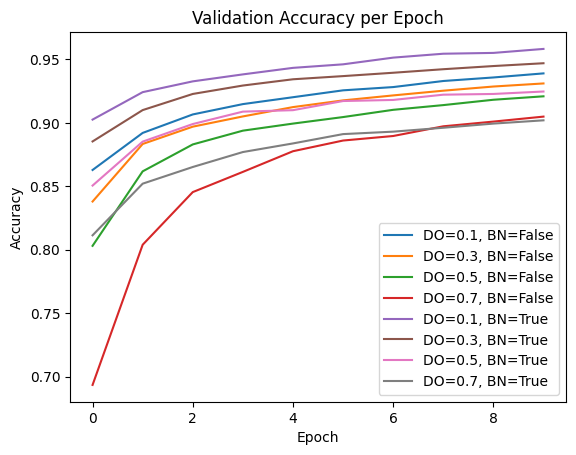

In [27]:
for res in results:
    label = f"DO={res['Dropout']}, BN={res['BatchNorm']}"
    plt.plot(res['Val Acc Curve'], label=label)

plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [28]:
# Find best Learning Rate
best_lr_result = max(results_lr, key=lambda x: x['Final Val Acc'])
best_lr = best_lr_result['LR']

# Find best Batch Size
best_bs_result = max(results_bs_enhanced, key=lambda x: x['Final Val Acc'])
best_batch_size = best_bs_result['Batch Size']

# Find best Architecture
best_arch_result = max(results_arch, key=lambda x: x['Final Val Acc'])
best_hidden_sizes = [best_arch_result['Neurons per Layer']] * best_arch_result['Layers']

# Find best Dropout + BatchNorm combination
best_reg_result = max(results, key=lambda x: x['Final Val Acc'])
best_dropout = best_reg_result['Dropout']
best_batchnorm = best_reg_result['BatchNorm']

# Collect all best hyperparameters
best_hyperparameters = [
    {'type': 'learning_rate', 'value': best_lr, 'val_acc': best_lr_result['Final Val Acc']},
    {'type': 'batch_size', 'value': best_batch_size, 'val_acc': best_bs_result['Final Val Acc']},
    {'type': 'architecture', 'value': best_hidden_sizes, 'val_acc': best_arch_result['Final Val Acc']},
    {'type': 'dropout', 'value': best_dropout, 'val_acc': best_reg_result['Final Val Acc']},
    {'type': 'batchnorm', 'value': best_batchnorm, 'val_acc': best_reg_result['Final Val Acc']}
]

# Create final best configuration combining all best hyperparameters
best_config = {
    "learning_rate": best_lr,
    "batch_size": best_batch_size,
    "hidden_layers": best_hidden_sizes,
    "dropout": best_dropout,
    "use_batchnorm": best_batchnorm
}

print("=" * 60)
print("BEST HYPERPARAMETERS FROM EACH EXPERIMENT:")
print("=" * 60)
for hp in best_hyperparameters:
    print(f"{hp['type']}: {hp['value']} (Val Acc: {hp['val_acc']:.4f})")

print("\n" + "=" * 60)
print("COMBINED BEST CONFIGURATION:")
print("=" * 60)
for key, value in best_config.items():
    print(f"{key}: {value}")

BEST HYPERPARAMETERS FROM EACH EXPERIMENT:
learning_rate: 0.1 (Val Acc: 0.9740)
batch_size: 16 (Val Acc: 0.9634)
architecture: [512, 512, 512, 512, 512] (Val Acc: 0.9624)
dropout: 0.1 (Val Acc: 0.9583)
batchnorm: True (Val Acc: 0.9583)

COMBINED BEST CONFIGURATION:
learning_rate: 0.1
batch_size: 16
hidden_layers: [512, 512, 512, 512, 512]
dropout: 0.1
use_batchnorm: True


In [29]:
def train_final_model(best_config, train_loader, val_loader, epochs=60, patience=5, min_delta=0.001, verbose=True):
    model = CustomNN(hidden_sizes=best_config['hidden_layers'],
                      dropout_prob=best_config['dropout'],
                      use_batchnorm=best_config['use_batchnorm'])

    print("\nTraining the final model with the best hyperparameters and Early Stopping...")

    # Use the best batch size for the final training and validation loaders
    train_loader_final, val_loader_final, _ = get_dataloaders(batch_size=best_config['batch_size'])

    # Incorporate early stopping in the final training
    final_history = train_model(model, train_loader_final, val_loader_final,
                                lr=best_config['learning_rate'], epochs=epochs,
                                patience=patience, min_delta=min_delta, verbose=True)

    return model, final_history

In [32]:
def predict_on_test_set(model, test_loader):
    model.to(device)
    model.eval() # Set model to evaluation mode
    criterion = nn.CrossEntropyLoss() # Use the same criterion as training

    test_loss, test_acc = run_epoch(model, test_loader, criterion)

    print("=" * 60)
    print("FINAL MODEL EVALUATION ON TEST SET:")
    print("=" * 60)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    return test_loss, test_acc

In [33]:
_, _, test_loader_final = get_dataloaders(batch_size=best_config['batch_size'])
# Train the model
final_model, final_history = train_final_model(best_config, train_loader, val_loader, epochs=75)

# Make predictions
test_loss, test_acc = predict_on_test_set(final_model, test_loader_final)


Training the final model with the best hyperparameters and Early Stopping...
Training with Early Stopping (patience=5, min_delta=0.001)
Epoch 1/75 | Train Loss: 0.4091 Acc: 0.8787 | Val Loss: 0.1395 Acc: 0.9564
Epoch 2/75 | Train Loss: 0.2158 Acc: 0.9347 | Val Loss: 0.0970 Acc: 0.9720
Epoch 3/75 | Train Loss: 0.1678 Acc: 0.9489 | Val Loss: 0.0880 Acc: 0.9739
Epoch 4/75 | Train Loss: 0.1324 Acc: 0.9590 | Val Loss: 0.0832 Acc: 0.9744
Epoch 5/75 | Train Loss: 0.1208 Acc: 0.9617 | Val Loss: 0.0782 Acc: 0.9756
Epoch 6/75 | Train Loss: 0.1072 Acc: 0.9659 | Val Loss: 0.0771 Acc: 0.9779
Epoch 7/75 | Train Loss: 0.0936 Acc: 0.9697 | Val Loss: 0.0679 Acc: 0.9786
Epoch 8/75 | Train Loss: 0.0833 Acc: 0.9739 | Val Loss: 0.0672 Acc: 0.9798
Epoch 9/75 | Train Loss: 0.0753 Acc: 0.9768 | Val Loss: 0.0630 Acc: 0.9799
Epoch 10/75 | Train Loss: 0.0700 Acc: 0.9784 | Val Loss: 0.0609 Acc: 0.9821
Epoch 11/75 | Train Loss: 0.0621 Acc: 0.9802 | Val Loss: 0.0715 Acc: 0.9781
Epoch 12/75 | Train Loss: 0.0617 Acc

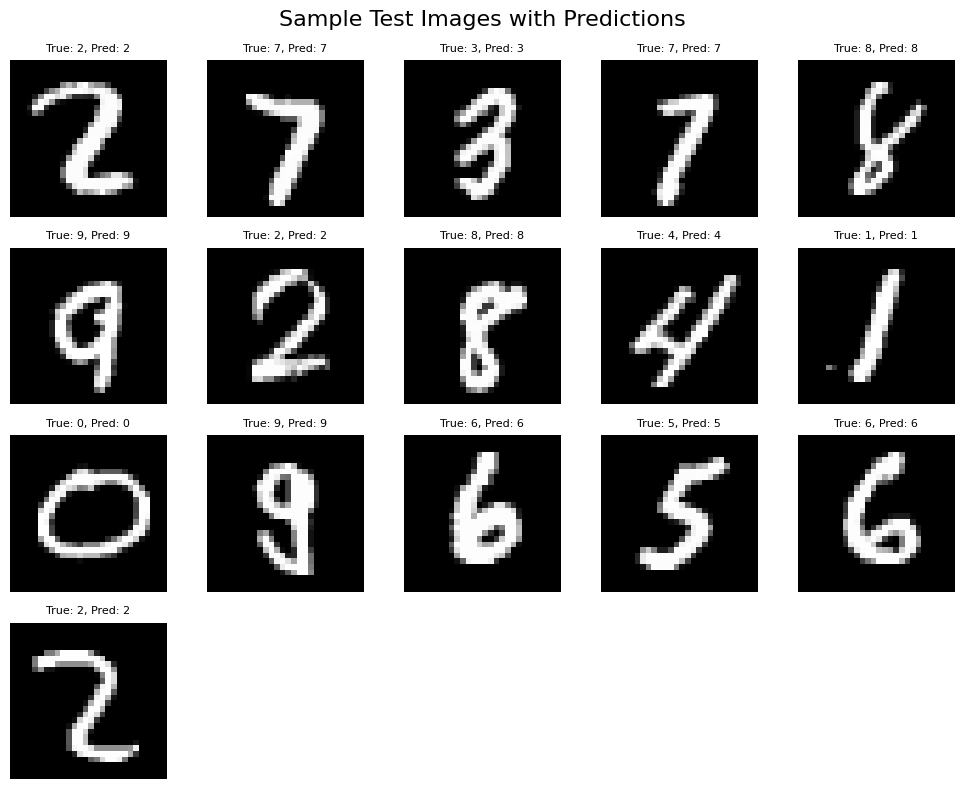

In [34]:
# Get a batch of images and labels from the test loader
dataiter = iter(test_loader_final)
images, labels = next(dataiter)

# Move images to the device (CPU or GPU) that the model is on
images = images.to(device)

# Get the model's predictions
final_model.eval()
with torch.no_grad():
    outputs = final_model(images)

# Get the predicted class for each image in the batch
_, predicted = torch.max(outputs.data, 1)

# Display multiple images with true and predicted labels
fig, axes = plt.subplots(4, 5, figsize=(10, 8)) # Create a grid of subplots
fig.suptitle("Sample Test Images with Predictions", fontsize=16)

# Iterate through a limited number of images in the batch (e.g., 20)
for idx, ax in enumerate(axes.flat):
    if idx < len(images): # Ensure we don't go out of bounds if batch size is less than 20
        img_to_show = images[idx].cpu().squeeze()
        true_label = labels[idx].item()
        predicted_label = predicted[idx].item()

        ax.imshow(img_to_show, cmap='gray')
        ax.set_title(f"True: {true_label}, Pred: {predicted_label}", fontsize=8)
        ax.axis('off')
    else:
        ax.axis('off') # Turn off unused subplots if batch size is small

plt.tight_layout()
plt.show()

In [37]:
import json
import os

def save_experiment_results(history, best_config, test_loss, test_acc, save_path="results"):

    os.makedirs(save_path, exist_ok=True)

    results = {
        "train_losses": history["train_losses"],
        "val_losses": history["val_losses"],
        "train_accs": history["train_accs"],
        "val_accs": history["val_accs"],
        "best_config": best_config,
        "final_test_loss": test_loss,
        "final_test_acc": test_acc
    }

    # Save to JSON
    results_file = os.path.join(save_path, "Custom Neural Network.json")
    with open(results_file, "w") as f:
        json.dump(results, f, indent=4)

    print(f"✅ Results saved to {results_file}")

save_experiment_results(final_history, best_config, test_loss, test_acc)


✅ Results saved to results/Custom Neural Network.json
